# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nfl_data_py as nfl

from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import ParameterGrid
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import xgboost as xgb
import shap
import optuna

from ELO import ELO

/Users/iggysiegel/opt/anaconda3/envs/sports_betting/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Import Data

In [2]:
data = pd.read_csv("data/data_engineering_2008_2024_15.csv")
data = data[data["season"] != 2010] # Drop first season due to data engineering

/var/folders/4p/33lbnggs2vz1ffh9zv619nnm0000gn/T/ipykernel_81496/149168617.py:1: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/data_engineering_2008_2024_15.csv")


In [3]:
features = [
    # General
    'home_elo_prob',
    'div_game',
    'is_playoff',
    'week',
    'away_rest',
    'home_rest',

    # Offense - Home
    'current_win_pctg_home',
    'last_win_pctg_home',
    'streak_home',
    'ats_pctg_home',
    'spread_differential_home',
    'drive_scoring_percentage_off_home',
    'qbr_home',
    'posteam_score_max_off_home',
    'yards_gained_sum_off_home',
    'total_time_of_posession_off_home',
    'total_plays_off_home',
    'complete_pass_sum_off_home',
    'passing_yards_sum_off_home',
    'pass_touchdown_sum_off_home',
    'rush_attempt_sum_off_home',
    'rushing_yards_sum_off_home',
    'rush_touchdown_sum_off_home',
    'third_down_conversion_rate_off_home',
    'penalty_yards_sum_off_home',
    'fumble_lost_sum_off_home',
    'net_turnovers_off_home',
    'qb_hit_sum_off_home',
    'sack_sum_off_home',
    'epa_sum_off_home',

    # Defense - Home
    'posteam_score_max_def_home',
    'yards_gained_sum_def_home',
    'total_plays_def_home',
    'fumble_lost_sum_def_home',
    'net_turnovers_def_home',
    'third_down_conversion_rate_def_home',
    'passing_yards_sum_def_home',
    'pass_touchdown_sum_def_home',
    'rushing_yards_sum_def_home',
    'rush_touchdown_sum_def_home',
    'qb_hit_sum_def_home',
    'sack_sum_def_home',
    'epa_sum_def_home',

    # Offense - Away
    'current_win_pctg_away',
    'last_win_pctg_away',
    'streak_away',
    'ats_pctg_away',
    'spread_differential_away',
    'drive_scoring_percentage_off_away',
    'qbr_away',
    'posteam_score_max_off_away',
    'yards_gained_sum_off_away',
    'total_time_of_posession_off_away',
    'total_plays_off_away',
    'complete_pass_sum_off_away',
    'passing_yards_sum_off_away',
    'pass_touchdown_sum_off_away',
    'rush_attempt_sum_off_away',
    'rushing_yards_sum_off_away',
    'rush_touchdown_sum_off_away',
    'third_down_conversion_rate_off_away',
    'penalty_yards_sum_off_away',
    'fumble_lost_sum_off_away',
    'net_turnovers_off_away',
    'qb_hit_sum_off_away',
    'sack_sum_off_away',
    'epa_sum_off_away',

    # Defense - Away
    'posteam_score_max_def_away',
    'yards_gained_sum_def_away',
    'total_plays_def_away',
    'fumble_lost_sum_def_away',
    'net_turnovers_def_away',
    'third_down_conversion_rate_def_away',
    'passing_yards_sum_def_away',
    'pass_touchdown_sum_def_away',
    'rushing_yards_sum_def_away',
    'rush_touchdown_sum_def_away',
    'qb_hit_sum_def_away',
    'sack_sum_def_away',
    'epa_sum_def_away'
]

# XGBoost / Hyperparameter Tuning

In [4]:
def prepare_data(data, train_seasons, test_seasons, features):
    """
    Prepare data for training and testing.

    Inputs:
        - data: pd.DataFrame, data
        - features: list, features to use
        - train_seasons: list, seasons to train on
        - test_seasons: list, seasons to test on
    Outputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - X_train: pd.DataFrame, training features
        - y_train: pd.Series, training labels
        - X_test: pd.DataFrame, testing features
        - y_test: pd.Series, testing labels
    """
    train_data = data[data["season"].isin(train_seasons)].dropna(subset = features)
    test_data = data[data["season"].isin(test_seasons)].dropna(subset = features)
    
    X_train = train_data[features]
    y_train = train_data["home_score"] + train_data["away_score"]
    X_test = test_data[features]
    y_test = test_data["home_score"] + test_data["away_score"]

    return train_data, test_data, X_train, y_train, X_test, y_test

In [5]:
def objective(trial, X_train, y_train):
    """
    Objective function for Optuna to optimize XGBoost hyperparameters for regression.

    Inputs:
        - trial: Optuna trial object
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Continuous target labels
    Outputs:
        - score: float, Validation RMSE score
    """
    # Define the hyperparameter search space
    param_grid = {
        "max_depth": trial.suggest_int("max_depth", 1, 5),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "learning_rate": trial.suggest_float("learning_rate", 0.0001, 0.1),
        "reg_alpha": trial.suggest_categorical("reg_alpha", [0.0, 0.1, 0.5, 1.0]),
        "reg_lambda": trial.suggest_categorical("reg_lambda", [0.0, 0.1, 0.5, 1.0, 5.0])
    }

    # Initialize the XGBoost model for regression
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = 10000,
        early_stopping_rounds = 10,
        **param_grid
    )

    # 5-fold cross validation
    kf = KFold(n_splits = 5)
    scores = []
    early_stopping = []
    for train_index, val_index in kf.split(X_train):
        X_t, X_v = X_train.iloc[train_index], X_train.iloc[val_index]
        y_t, y_v = y_train.iloc[train_index], y_train.iloc[val_index]
        model.fit(
            X_t,
            y_t,
            eval_set = [(X_v, y_v)],
            verbose = False
        )
        preds = model.predict(X_v)
        scores.append(metrics.root_mean_squared_error(y_v, preds))
        early_stopping.append(model.best_iteration)
    trial.set_user_attr("early_stopping", int(sum(early_stopping) / len(early_stopping)))

    # Return the mean validation RMSE
    return sum(scores) / len(scores)

In [6]:
def tune_hyperparameters(X_train, y_train, n_trials):
    """
    Run Optuna hyperparameter tuning.

    Inputs:
        - X_train: pd.DataFrame, Input features
        - y_train: pd.Series, Input labels
        - n_trials: int, Number of optimization trials
    Output:
        - study: Optuna study object
    """
    study = optuna.create_study(direction = "minimize")
    study.optimize(lambda trial: objective(trial, X_train, y_train), n_trials = n_trials)
    return study

In [7]:
def betting_simulation(train_data, test_data, confidence = 1.0):
    """ 
    Simulate betting on games based on model predictions.

    Inputs:
        - train_data: pd.DataFrame, training data
        - test_data: pd.DataFrame, testing data
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
    Outputs:
        - overall_accuracy: float, overall accuracy of betting strategy
        - total_games: int, total number of games bet on
        
    The function evaluates betting outcomes by comparing model predictions to the spread lines. If the 
    difference between the model predictions and spread lines is greater than the threshold, the function
    bets on the game.
    """
    # Determine threshold for high-confidence bets
    threshold = confidence * np.std(train_data["difference"])

    # Initialize counters
    num_correct_total = 0
    num_incorrect_total = 0
    
    # Iterate through each week
    for week in test_data["week"].unique():
        week_data = test_data[test_data["week"] == week]
        num_correct_week = 0
        num_incorrect_week = 0
        for row in week_data.itertuples():
            if row.difference > threshold:
                if (
                    (row.predictions < row.total_line and (row.home_score + row.away_score) < row.total_line) or
                    (row.predictions > row.total_line and (row.home_score + row.away_score) > row.total_line)
                ):                    
                    num_correct_week += 1
                    num_correct_total += 1
                else:
                    num_incorrect_week += 1
                    num_incorrect_total += 1

        # Calculate and print weekly accuracy
        total_week_games = num_correct_week + num_incorrect_week
        if total_week_games > 0:
            weekly_accuracy = num_correct_week / total_week_games
            print(f"Week {week:<2}: {weekly_accuracy:.4f} ({num_correct_week}/{total_week_games})")

    # Calculate and print overall accuracy
    total_games = num_correct_total + num_incorrect_total
    if total_games > 0:
        overall_accuracy = num_correct_total / total_games
        print(f"\nSeason Accuracy: {overall_accuracy:.4f} ({num_correct_total}/{total_games})")

    return overall_accuracy, total_games

In [8]:
def main(data, train_seasons, test_seasons, features, n_trials = 100, confidence = 1.0, shapley = False):
    """ 
    Main function to train a machine learning model for NFL game predictions.

    This function prepares the data, tunes hyperparameters, trains the model, and simulates betting outcomes
    based on the model's predictions.

    Inputs:
        - data: pd.DataFrame, full dataset containing game data
        - train_seasons: list, seasons used for training the model
        - test_seasons: list, seasons used for testing the model
        - features: list, feature columns used for model training and predictions
        - n_trials: int, number of trials for hyperparameter optimization (default is 100)
        - confidence: float, number of standard deviations to define high-confidence bets (default is 1.0)
        - shapley: bool, whether to plot SHAP values (default is False)
    Outputs:
        - train_data: pd.DataFrame, training data with model predictions
        - test_data: pd.DataFrame, testing data with model predictions
        - model: Fit XGBoost model
    """
    # Prepare data
    train_data, test_data, X_train, y_train, X_test, y_test = prepare_data(data, train_seasons, test_seasons, features)

    # Tune hyperparameters
    study = tune_hyperparameters(X_train, y_train, n_trials)
    print("Best Optuna parameters:", study.best_params)
    print("Best Optuna score:", study.best_value)
    print()

    # Fit the model with the best hyperparameters
    model = xgb.XGBRegressor(
        objective = "reg:squarederror",
        eval_metric = "rmse",
        n_estimators = study.best_trial.user_attrs["early_stopping"],
        **study.best_params
    )
    model.fit(X_train, y_train)

    # Store predictions and differences
    train_data["predictions"] = model.predict(X_train)
    train_data["difference"] = abs(train_data["predictions"] - train_data["total_line"])
    test_data["predictions"] = model.predict(X_test)
    test_data["difference"] = abs(test_data["predictions"] - test_data["total_line"])

    # Shapley plot
    if shapley:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_train)
        plt.figure(figsize = (20, 12))
        shap.summary_plot(shap_values, X_train, show = True, max_display = 20, plot_type = "violin")
        plt.show()

    # Betting simulation
    _, _ = betting_simulation(train_data, test_data, confidence)

    return train_data, test_data, model

# Performance

In [9]:
N_TRIALS = 100
CONFIDENCE = 2.0

[I 2024-12-28 12:06:01,989] A new study created in memory with name: no-name-e9b8f428-eec8-4085-8d63-4257ae60c0a3
[I 2024-12-28 12:06:02,835] Trial 0 finished with value: 13.592041748563805 and parameters: {'max_depth': 3, 'subsample': 0.5969186772692243, 'colsample_bytree': 0.9869592831394551, 'learning_rate': 0.09870299876956702, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 0 with value: 13.592041748563805.
[I 2024-12-28 12:06:06,441] Trial 1 finished with value: 13.607026609589 and parameters: {'max_depth': 2, 'subsample': 0.811881203551855, 'colsample_bytree': 0.8969579166366806, 'learning_rate': 0.006333967806592855, 'reg_alpha': 0.0, 'reg_lambda': 0.5}. Best is trial 0 with value: 13.592041748563805.
[I 2024-12-28 12:06:07,389] Trial 2 finished with value: 13.592422341735551 and parameters: {'max_depth': 2, 'subsample': 0.9392133103776423, 'colsample_bytree': 0.8983480579390832, 'learning_rate': 0.04971398781620336, 'reg_alpha': 0.5, 'reg_lambda': 0.1}. Best is trial 0 wit

Best Optuna parameters: {'max_depth': 3, 'subsample': 0.513828426361158, 'colsample_bytree': 0.8409403655906139, 'learning_rate': 0.059980223086439056, 'reg_alpha': 0.5, 'reg_lambda': 0.5}
Best Optuna score: 13.527075196844924



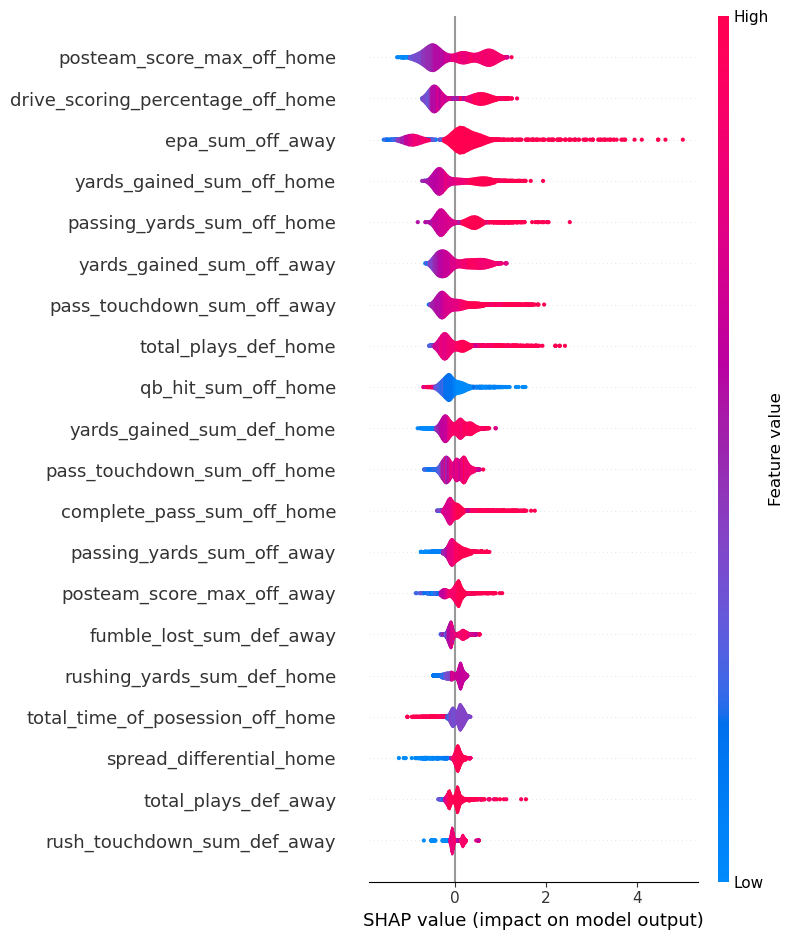

Week 1 : 0.3333 (1/3)
Week 2 : 0.3333 (1/3)
Week 3 : 0.4000 (2/5)
Week 4 : 0.6667 (2/3)
Week 5 : 0.6000 (3/5)
Week 6 : 0.8000 (4/5)
Week 7 : 0.7500 (3/4)
Week 8 : 0.4000 (2/5)
Week 9 : 0.0000 (0/2)
Week 10: 0.3333 (1/3)
Week 11: 1.0000 (1/1)
Week 12: 0.5000 (3/6)
Week 13: 0.6667 (2/3)
Week 14: 0.3333 (1/3)
Week 15: 0.6667 (2/3)

Season Accuracy: 0.5185 (28/54)


In [10]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
test_seasons = [2024]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:08:23,428] A new study created in memory with name: no-name-5c684288-eee4-4e8f-8e7a-c354ef2210ae
[I 2024-12-28 12:08:24,091] Trial 0 finished with value: 13.568846307599639 and parameters: {'max_depth': 2, 'subsample': 0.5156353438737088, 'colsample_bytree': 0.5593490183154912, 'learning_rate': 0.09425716933562572, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.568846307599639.
[I 2024-12-28 12:08:24,982] Trial 1 finished with value: 13.624816312745441 and parameters: {'max_depth': 4, 'subsample': 0.9890267536651477, 'colsample_bytree': 0.8063837284477908, 'learning_rate': 0.045603241515177764, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.568846307599639.
[I 2024-12-28 12:08:25,902] Trial 2 finished with value: 13.56986245012961 and parameters: {'max_depth': 3, 'subsample': 0.8180730112666363, 'colsample_bytree': 0.5860784532466243, 'learning_rate': 0.0424901934219294, 'reg_alpha': 0.0, 'reg_lambda': 1.0}. Best is trial 0 w

Best Optuna parameters: {'max_depth': 3, 'subsample': 0.603262381635358, 'colsample_bytree': 0.5613025774204226, 'learning_rate': 0.04190584222260841, 'reg_alpha': 1.0, 'reg_lambda': 0.5}
Best Optuna score: 13.530655921645007



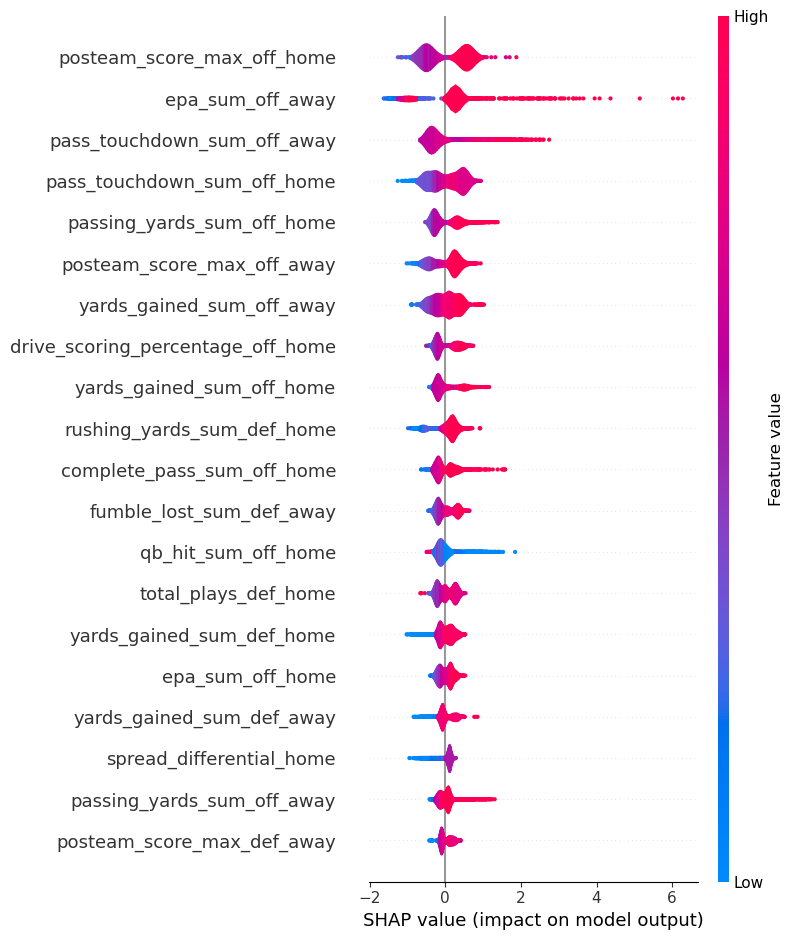

Week 1 : 0.5000 (1/2)
Week 2 : 0.6667 (2/3)
Week 3 : 0.5000 (1/2)
Week 4 : 0.5000 (1/2)
Week 5 : 0.7500 (3/4)
Week 6 : 0.0000 (0/1)
Week 7 : 0.2500 (1/4)
Week 8 : 0.5000 (2/4)
Week 9 : 0.6000 (3/5)
Week 10: 0.0000 (0/2)
Week 11: 0.2000 (1/5)
Week 12: 0.2500 (1/4)
Week 13: 0.2000 (1/5)
Week 14: 1.0000 (4/4)
Week 15: 0.4286 (3/7)
Week 16: 0.5000 (2/4)
Week 17: 0.4737 (9/19)

Season Accuracy: 0.4545 (35/77)


In [11]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
test_seasons = [2023]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:13:14,532] A new study created in memory with name: no-name-8ea97833-7c2c-4dd0-ac98-a2cac05dc107
[I 2024-12-28 12:13:15,260] Trial 0 finished with value: 13.585423426379972 and parameters: {'max_depth': 2, 'subsample': 0.5449240638526072, 'colsample_bytree': 0.5442213814380148, 'learning_rate': 0.0876567684906484, 'reg_alpha': 0.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.585423426379972.
[I 2024-12-28 12:13:16,254] Trial 1 finished with value: 13.636270659290991 and parameters: {'max_depth': 5, 'subsample': 0.9444359885738097, 'colsample_bytree': 0.9917873588118832, 'learning_rate': 0.08151641279681379, 'reg_alpha': 0.1, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.585423426379972.
[I 2024-12-28 12:13:17,079] Trial 2 finished with value: 13.605027069971726 and parameters: {'max_depth': 1, 'subsample': 0.5663656167618387, 'colsample_bytree': 0.7893057922732916, 'learning_rate': 0.07123682696055887, 'reg_alpha': 0.5, 'reg_lambda': 0.0}. Best is trial 0 w

Best Optuna parameters: {'max_depth': 4, 'subsample': 0.6998791253181368, 'colsample_bytree': 0.6013391763859568, 'learning_rate': 0.04138510702095979, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Best Optuna score: 13.520847289688927



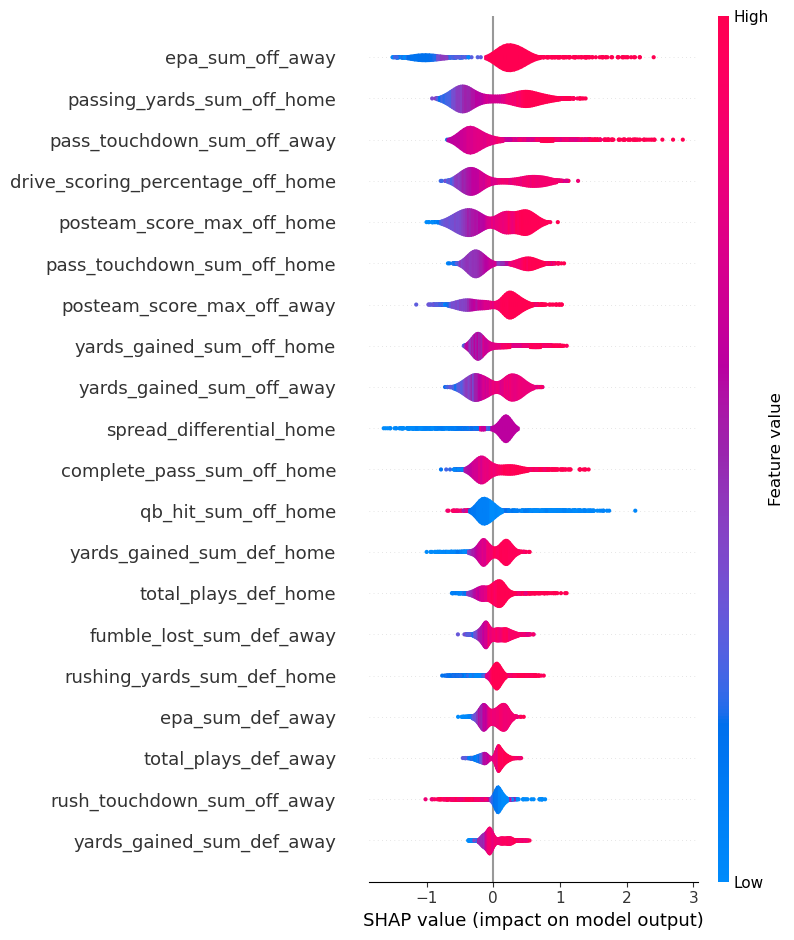

Week 1 : 0.2000 (1/5)
Week 2 : 0.2500 (1/4)
Week 3 : 0.6667 (2/3)
Week 4 : 0.6667 (2/3)
Week 5 : 1.0000 (1/1)
Week 6 : 0.3333 (1/3)
Week 7 : 0.0000 (0/1)
Week 8 : 0.0000 (0/1)
Week 9 : 0.0000 (0/1)
Week 10: 0.5000 (2/4)
Week 11: 0.3333 (1/3)
Week 12: 0.3333 (1/3)
Week 13: 0.0000 (0/1)
Week 14: 0.6667 (2/3)
Week 15: 0.4286 (3/7)
Week 16: 0.2857 (2/7)
Week 17: 0.5455 (6/11)

Season Accuracy: 0.4098 (25/61)


In [12]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_seasons = [2022]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:15:43,284] A new study created in memory with name: no-name-bab73ed9-7762-4d8b-a813-bf7c599a9c6b
[I 2024-12-28 12:15:44,352] Trial 0 finished with value: 13.555260234033103 and parameters: {'max_depth': 3, 'subsample': 0.5545420496209534, 'colsample_bytree': 0.7232653176351185, 'learning_rate': 0.03826338055174395, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.555260234033103.
[I 2024-12-28 12:15:45,231] Trial 1 finished with value: 13.611049690698431 and parameters: {'max_depth': 4, 'subsample': 0.693218055641941, 'colsample_bytree': 0.8110713329251948, 'learning_rate': 0.06818505102776089, 'reg_alpha': 0.5, 'reg_lambda': 1.0}. Best is trial 0 with value: 13.555260234033103.
[I 2024-12-28 12:15:46,064] Trial 2 finished with value: 13.698232118941934 and parameters: {'max_depth': 5, 'subsample': 0.9538319232953166, 'colsample_bytree': 0.7638294203442866, 'learning_rate': 0.09715690003151199, 'reg_alpha': 0.1, 'reg_lambda': 0.0}. Best is trial 0 w

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.5451702315638047, 'colsample_bytree': 0.5271012045086949, 'learning_rate': 0.059466821316904506, 'reg_alpha': 0.1, 'reg_lambda': 5.0}
Best Optuna score: 13.538078068801846



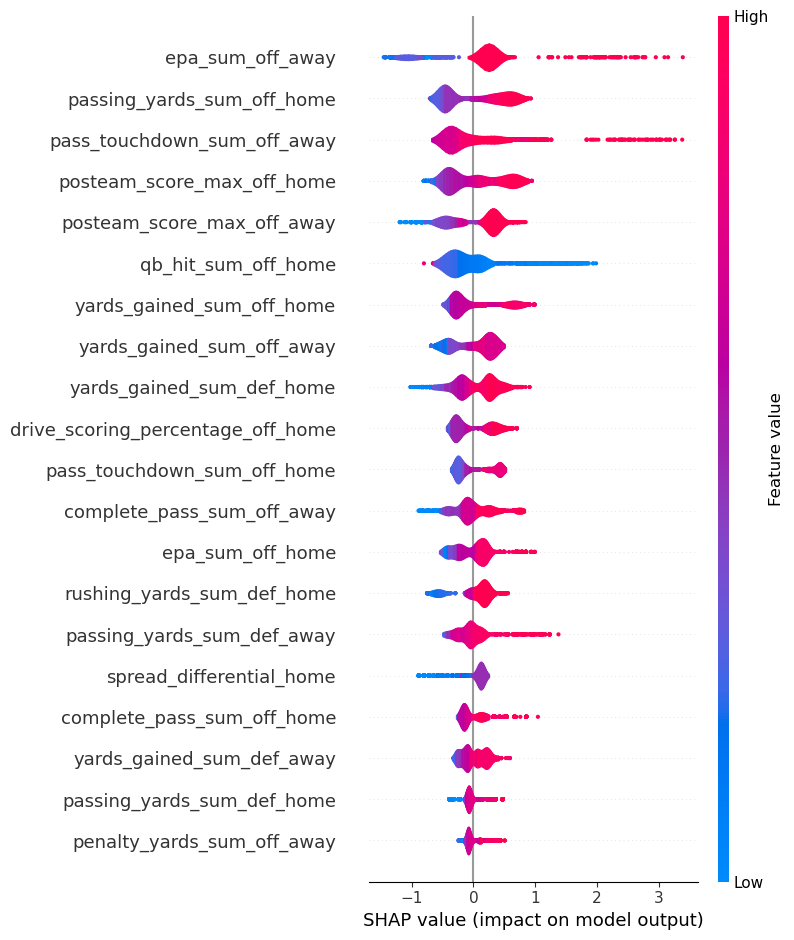

Week 1 : 0.5000 (1/2)
Week 2 : 0.6667 (2/3)
Week 3 : 0.6667 (2/3)
Week 4 : 0.0000 (0/3)
Week 5 : 0.5000 (2/4)
Week 6 : 0.0000 (0/3)
Week 7 : 0.5000 (2/4)
Week 8 : 0.3333 (1/3)
Week 9 : 1.0000 (2/2)
Week 10: 0.5000 (2/4)
Week 11: 1.0000 (3/3)
Week 12: 1.0000 (1/1)
Week 13: 0.3333 (1/3)
Week 14: 1.0000 (1/1)
Week 15: 0.6000 (3/5)
Week 16: 0.6667 (2/3)
Week 17: 0.5385 (7/13)

Season Accuracy: 0.5333 (32/60)


In [13]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]
test_seasons = [2021]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:18:17,910] A new study created in memory with name: no-name-64f9fa04-5927-4c92-bca2-5b177709a83b
[I 2024-12-28 12:18:18,732] Trial 0 finished with value: 13.605815139805362 and parameters: {'max_depth': 5, 'subsample': 0.8500407695917636, 'colsample_bytree': 0.7399426436128933, 'learning_rate': 0.09821651845658942, 'reg_alpha': 0.0, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.605815139805362.
[I 2024-12-28 12:18:19,445] Trial 1 finished with value: 13.578388518568667 and parameters: {'max_depth': 2, 'subsample': 0.842662471135526, 'colsample_bytree': 0.8214661353480617, 'learning_rate': 0.098534987375365, 'reg_alpha': 1.0, 'reg_lambda': 0.5}. Best is trial 1 with value: 13.578388518568667.
[I 2024-12-28 12:18:20,900] Trial 2 finished with value: 13.61705224341741 and parameters: {'max_depth': 5, 'subsample': 0.8521797306024015, 'colsample_bytree': 0.8858122091243312, 'learning_rate': 0.03445460072033718, 'reg_alpha': 1.0, 'reg_lambda': 0.0}. Best is trial 1 with

Best Optuna parameters: {'max_depth': 3, 'subsample': 0.5028818813595295, 'colsample_bytree': 0.5934891333593968, 'learning_rate': 0.022083629323062477, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
Best Optuna score: 13.493681286125673



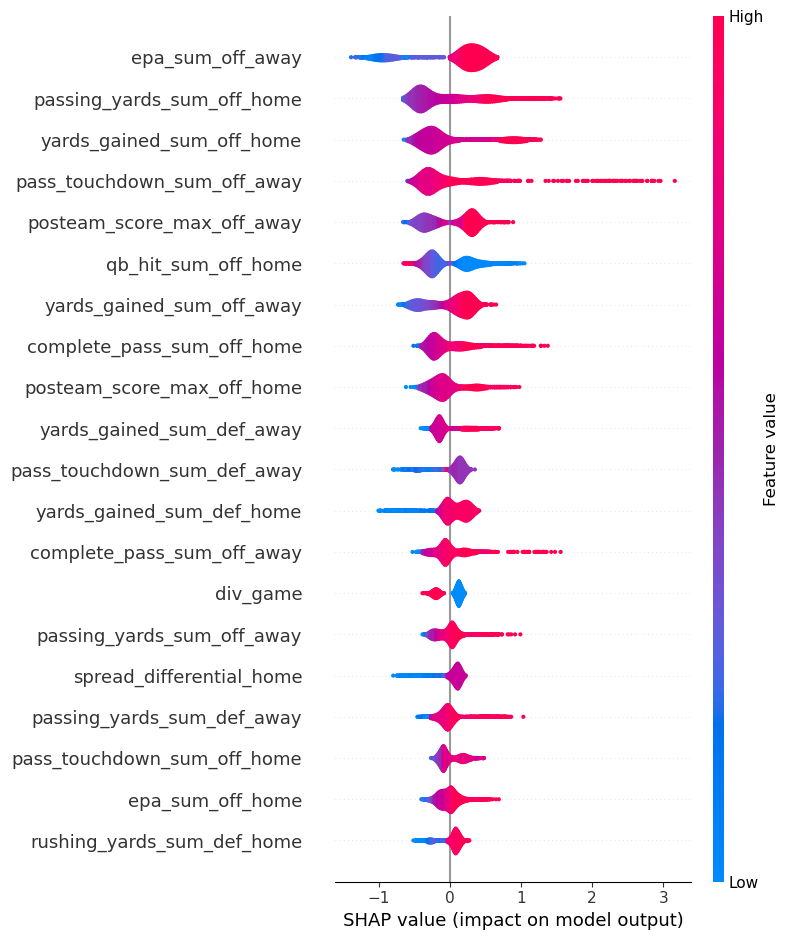

Week 1 : 0.0000 (0/1)
Week 2 : 0.6000 (3/5)
Week 3 : 0.6667 (2/3)
Week 4 : 0.2857 (2/7)
Week 5 : 0.8000 (4/5)
Week 6 : 0.7143 (5/7)
Week 7 : 0.5000 (2/4)
Week 8 : 0.5000 (3/6)
Week 9 : 0.4000 (2/5)
Week 10: 0.5000 (2/4)
Week 11: 0.5000 (2/4)
Week 12: 0.3750 (3/8)
Week 13: 0.0000 (0/3)
Week 14: 0.8000 (4/5)
Week 15: 0.0000 (0/5)
Week 16: 0.3333 (1/3)
Week 17: 0.4000 (2/5)
Week 18: 1.0000 (6/6)

Season Accuracy: 0.5000 (43/86)


In [14]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
test_seasons = [2020]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:21:03,022] A new study created in memory with name: no-name-2c0dc965-e38f-4b8c-993c-9d81f182acb7
[I 2024-12-28 12:21:03,762] Trial 0 finished with value: 13.615804467291577 and parameters: {'max_depth': 4, 'subsample': 0.8377723906537948, 'colsample_bytree': 0.664351024832396, 'learning_rate': 0.08337928817015089, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 0 with value: 13.615804467291577.
[I 2024-12-28 12:21:04,850] Trial 1 finished with value: 13.524359407346102 and parameters: {'max_depth': 2, 'subsample': 0.7549014614242835, 'colsample_bytree': 0.7445689735939081, 'learning_rate': 0.03541403938596584, 'reg_alpha': 1.0, 'reg_lambda': 0.1}. Best is trial 1 with value: 13.524359407346102.
[I 2024-12-28 12:21:07,083] Trial 2 finished with value: 13.565073456291554 and parameters: {'max_depth': 1, 'subsample': 0.585472629270394, 'colsample_bytree': 0.7952848260795546, 'learning_rate': 0.011486958046669368, 'reg_alpha': 0.0, 'reg_lambda': 5.0}. Best is trial 1 w

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.744019445313135, 'colsample_bytree': 0.5261508707435597, 'learning_rate': 0.09257106414294325, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
Best Optuna score: 13.45389828443582



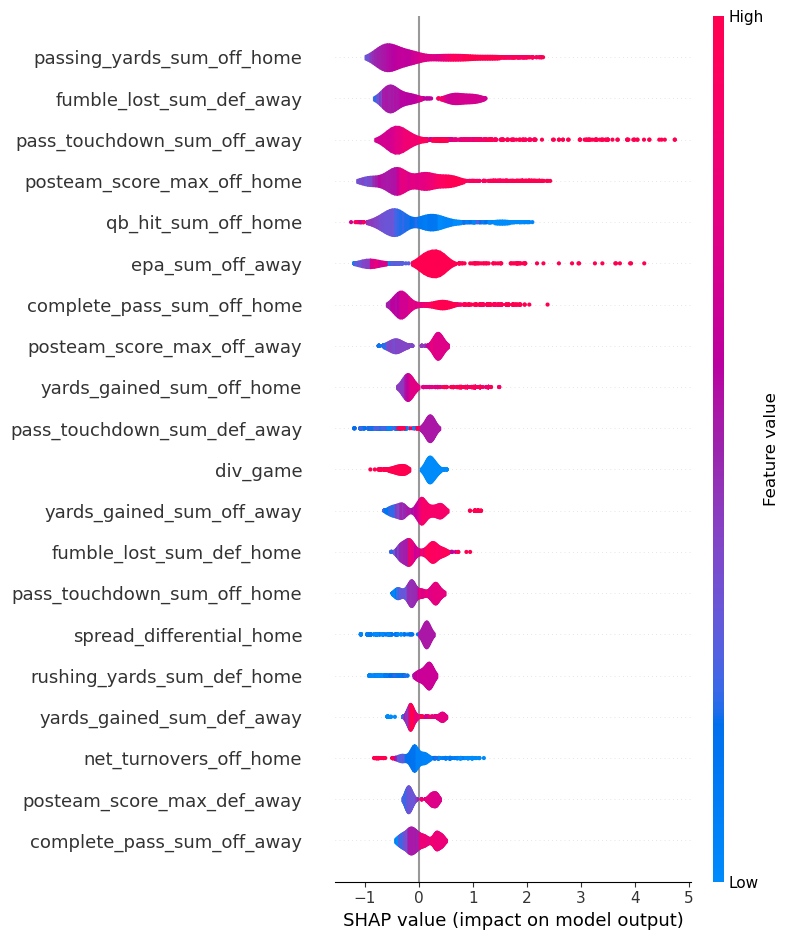

Week 1 : 0.5000 (1/2)
Week 2 : 0.5000 (4/8)
Week 4 : 0.5000 (1/2)
Week 5 : 1.0000 (3/3)
Week 6 : 0.3333 (1/3)
Week 7 : 0.7500 (3/4)
Week 8 : 1.0000 (1/1)
Week 9 : 0.6000 (3/5)
Week 10: 0.0000 (0/3)
Week 11: 0.7500 (3/4)
Week 12: 0.0000 (0/1)
Week 13: 0.6667 (2/3)
Week 14: 0.6667 (2/3)
Week 15: 0.6000 (3/5)
Week 16: 0.6000 (3/5)
Week 17: 0.6667 (2/3)

Season Accuracy: 0.5818 (32/55)


In [15]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]
test_seasons = [2019]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)

[I 2024-12-28 12:22:25,692] A new study created in memory with name: no-name-1d31d262-68d2-44b6-b85d-7f74d8060563
[I 2024-12-28 12:22:26,341] Trial 0 finished with value: 13.38622335964023 and parameters: {'max_depth': 2, 'subsample': 0.5932807883489346, 'colsample_bytree': 0.5347153844592447, 'learning_rate': 0.06393835244520335, 'reg_alpha': 0.5, 'reg_lambda': 5.0}. Best is trial 0 with value: 13.38622335964023.
[I 2024-12-28 12:22:27,233] Trial 1 finished with value: 13.49107356706008 and parameters: {'max_depth': 5, 'subsample': 0.892082644741358, 'colsample_bytree': 0.8594519193282878, 'learning_rate': 0.07015680426788817, 'reg_alpha': 1.0, 'reg_lambda': 1.0}. Best is trial 0 with value: 13.38622335964023.
[I 2024-12-28 12:22:27,928] Trial 2 finished with value: 13.491584061567465 and parameters: {'max_depth': 4, 'subsample': 0.9079066581069183, 'colsample_bytree': 0.5146527902552065, 'learning_rate': 0.08512774970211488, 'reg_alpha': 0.5, 'reg_lambda': 0.1}. Best is trial 0 with 

Best Optuna parameters: {'max_depth': 2, 'subsample': 0.5322491966758054, 'colsample_bytree': 0.6007645031514698, 'learning_rate': 0.09861681846822846, 'reg_alpha': 1.0, 'reg_lambda': 5.0}
Best Optuna score: 13.323778825884721



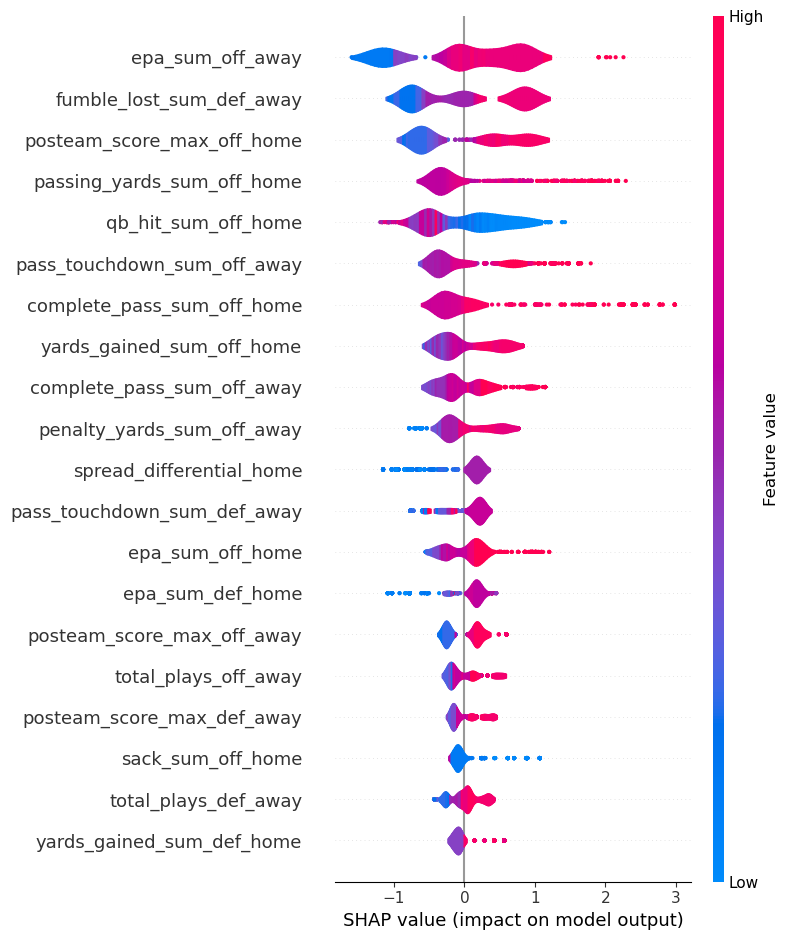

Week 1 : 0.3333 (1/3)
Week 2 : 0.4286 (3/7)
Week 3 : 0.3333 (2/6)
Week 4 : 0.6250 (5/8)
Week 5 : 0.0000 (0/3)
Week 6 : 0.4000 (2/5)
Week 7 : 0.5000 (1/2)
Week 8 : 0.7500 (3/4)
Week 9 : 0.5000 (2/4)
Week 10: 0.6667 (2/3)
Week 11: 0.6000 (3/5)
Week 12: 0.8000 (4/5)
Week 13: 0.5000 (2/4)
Week 14: 1.0000 (2/2)
Week 15: 0.0000 (0/2)
Week 16: 0.0000 (0/2)
Week 17: 0.5714 (4/7)
Week 18: 0.2500 (1/4)

Season Accuracy: 0.4868 (37/76)


In [16]:
train_seasons = [2011, 2012, 2013, 2014, 2015, 2016, 2017]
test_seasons = [2018]

train_data, test_data, model = main(
    data,
    train_seasons,
    test_seasons,
    features,
    n_trials = N_TRIALS,
    confidence = CONFIDENCE,
    shapley = True
)